# Упражнения к главе 11

In [2]:
import numpy as np

import os
import sys

PI2 = 2 * np.pi

module_dir = os.path.join(os.getcwd(), "..")
sys.path.insert(0, module_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

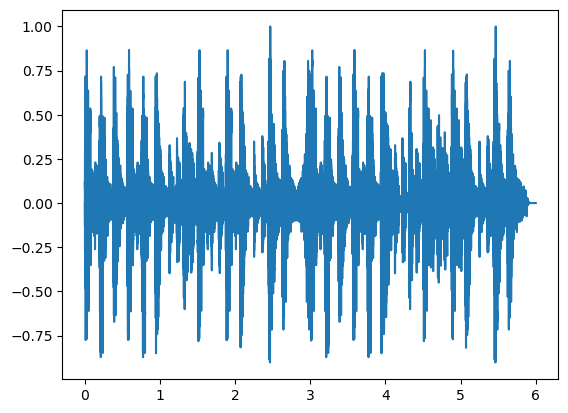

In [5]:
from thinkdsp import read_wave

wave = read_wave('263868__kevcio__amen-break-a-160-bpm.wav')
wave.normalize()
wave.plot()

In [6]:
wave.make_audio()

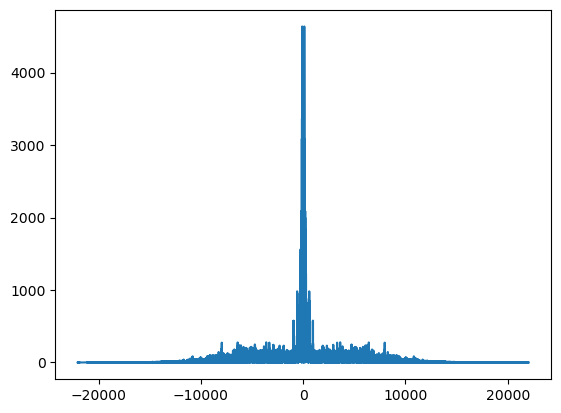

In [7]:
spectrum = wave.make_spectrum(full=True)
spectrum.plot()

In [8]:
factor = 3
framerate = wave.framerate / factor
cutoff = framerate / 2 - 1

In [9]:
filtered = spectrum.make_wave()
filtered.make_audio()

In [10]:
from thinkdsp import Wave

def sample(wave, factor):
    """Simulates sampling of a wave.
    
    wave: Wave object
    factor: ratio of the new framerate to the original
    """
    ys = np.zeros(len(wave))
    ys[::factor] = np.real(wave.ys[::factor])
    return Wave(ys, framerate=wave.framerate) 

In [11]:
sampled = sample(filtered, factor)
sampled.make_audio()

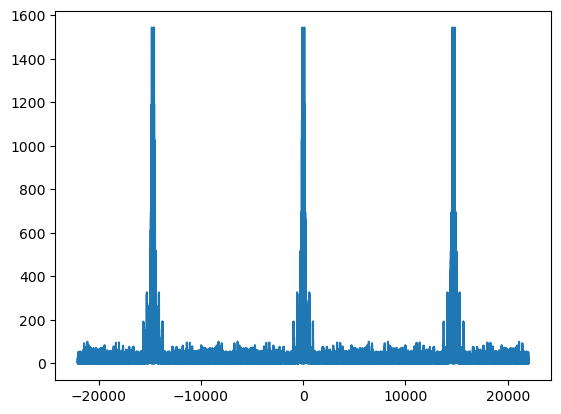

In [12]:
sampled_spectrum = sampled.make_spectrum(full=True)
sampled_spectrum.plot()

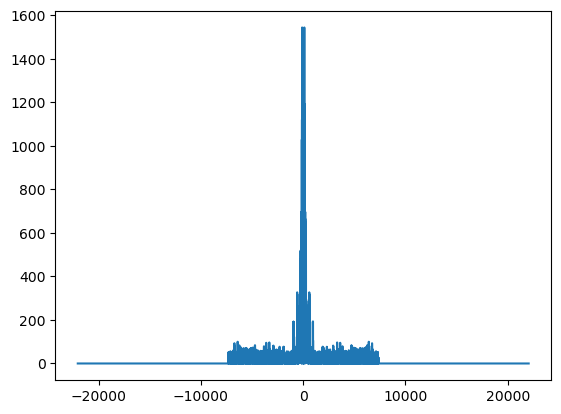

In [13]:
sampled_spectrum.low_pass(cutoff)
sampled_spectrum.plot()

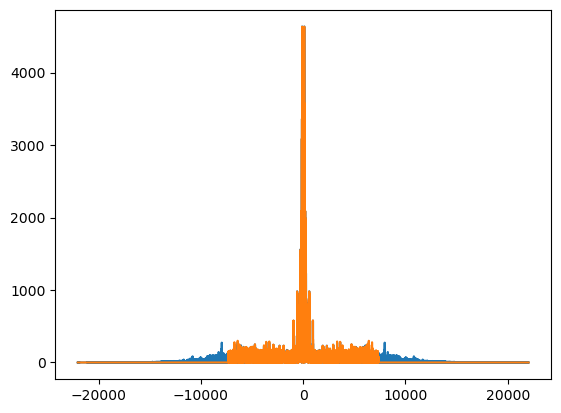

In [14]:
sampled_spectrum.scale(factor)
spectrum.plot()
sampled_spectrum.plot()

In [15]:
spectrum.max_diff(sampled_spectrum)

np.float64(273.7849555761336)

In [16]:
interpolated = sampled_spectrum.make_wave()
interpolated.make_audio()

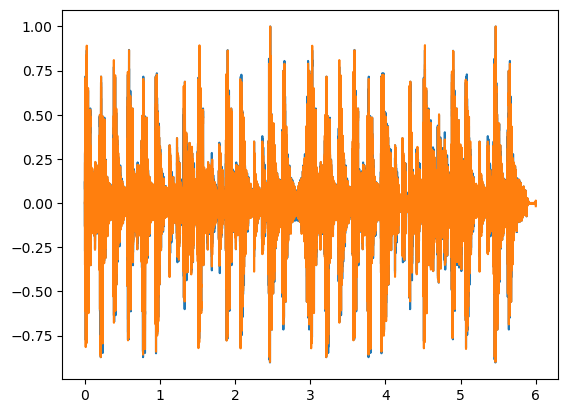

In [17]:
filtered.plot()
interpolated.plot()

In [18]:
filtered.max_diff(interpolated)

np.float64(0.24964127415020587)